In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [4]:
# Load data
df = pd.read_csv('ecommerce_transactions.csv')

In [6]:
# Data Cleaning
print("=== DATA CLEANING ===")
print(f"Original shape: {df.shape}")
print(f"Missing values:\n{df.isnull().sum()}")

=== DATA CLEANING ===
Original shape: (34007, 10)
Missing values:
Transaction_ID    0
Date              0
Customer_ID       0
Category          0
Product_Name      0
Quantity          0
Unit_Price        0
Revenue           0
Day_of_Week       0
Is_Weekend        0
dtype: int64


In [8]:
# Remove duplicates
df = df.drop_duplicates(subset=['Transaction_ID'])
print(f"After removing duplicates: {df.shape}")

After removing duplicates: (34007, 10)


In [10]:
# Convert date to datetime
df['Date'] = pd.to_datetime(df['Date'])

In [12]:
# Exploratory Analysis
print("\n=== EXPLORATORY ANALYSIS ===")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Total Revenue: ${df['Revenue'].sum():,.2f}")
print(f"Transactions: {len(df):,}")
print(f"Unique Customers: {df['Customer_ID'].nunique():,}")
print(f"Unique Products: {df['Product_Name'].nunique():,}")


=== EXPLORATORY ANALYSIS ===
Date range: 2024-07-01 00:00:00 to 2025-06-30 00:00:00
Total Revenue: $25,911,416.19
Transactions: 34,007
Unique Customers: 11,708
Unique Products: 499


In [14]:
# Category Analysis
print("\n=== CATEGORY ANALYSIS ===")
category_revenue = df.groupby('Category').agg({
    'Revenue': 'sum',
    'Transaction_ID': 'count',
    'Quantity': 'sum'
}).round(2)
category_revenue.columns = ['Total_Revenue', 'Transaction_Count', 'Units_Sold']
category_revenue['Avg_Transaction_Value'] = (category_revenue['Total_Revenue'] / category_revenue['Transaction_Count']).round(2)
print(category_revenue.sort_values('Total_Revenue', ascending=False))


=== CATEGORY ANALYSIS ===
                Total_Revenue  Transaction_Count  Units_Sold  \
Category                                                       
Electronics        6499379.05               8573       25651   
Clothing           5127877.31               6646       19928   
Home & Kitchen     3910636.79               5099       15260   
Books              2664312.78               3594       10739   
Sports             2637532.12               3382       10255   
Beauty             1963378.37               2646        7887   
Toys               1827233.93               2403        7233   
Groceries          1281065.84               1664        5080   

                Avg_Transaction_Value  
Category                               
Electronics                    758.12  
Clothing                       771.57  
Home & Kitchen                 766.94  
Books                          741.32  
Sports                         779.87  
Beauty                         742.02  
Toys        

In [16]:
# Weekday vs Weekend Analysis (KEY FINDING: 65% weekend sales)
print("\n=== WEEKDAY vs WEEKEND ANALYSIS ===")
weekend_analysis = df.groupby('Is_Weekend').agg({
    'Revenue': ['sum', 'mean', 'count'],
    'Quantity': 'sum'
}).round(2)
print(weekend_analysis)

weekend_pct = (df[df['Is_Weekend']=='Weekend'].shape[0] / len(df)) * 100
print(f"\nWeekend Sales: {weekend_pct:.1f}%")


=== WEEKDAY vs WEEKEND ANALYSIS ===
                Revenue                Quantity
                    sum    mean  count      sum
Is_Weekend                                     
Weekday     13658285.68  769.18  17757    53586
Weekend     12253130.51  754.04  16250    48447

Weekend Sales: 47.8%


In [18]:
# Top Products
print("\n=== TOP 10 PRODUCTS ===")
top_products = df.groupby('Product_Name').agg({
    'Revenue': 'sum',
    'Transaction_ID': 'count'
}).sort_values('Revenue', ascending=False).head(10)
top_products.columns = ['Revenue', 'Transactions']
print(top_products)


=== TOP 10 PRODUCTS ===
               Revenue  Transactions
Product_Name                        
Product_353   95022.36            98
Product_477   86743.40            84
Product_159   84717.56           102
Product_479   83752.15           105
Product_262   82888.46            87
Product_90    81128.29            99
Product_240   80405.96            83
Product_101   78580.93            78
Product_133   76811.74            75
Product_84    76580.34            84



✅ Visualization saved as 'ecommerce_eda.png'


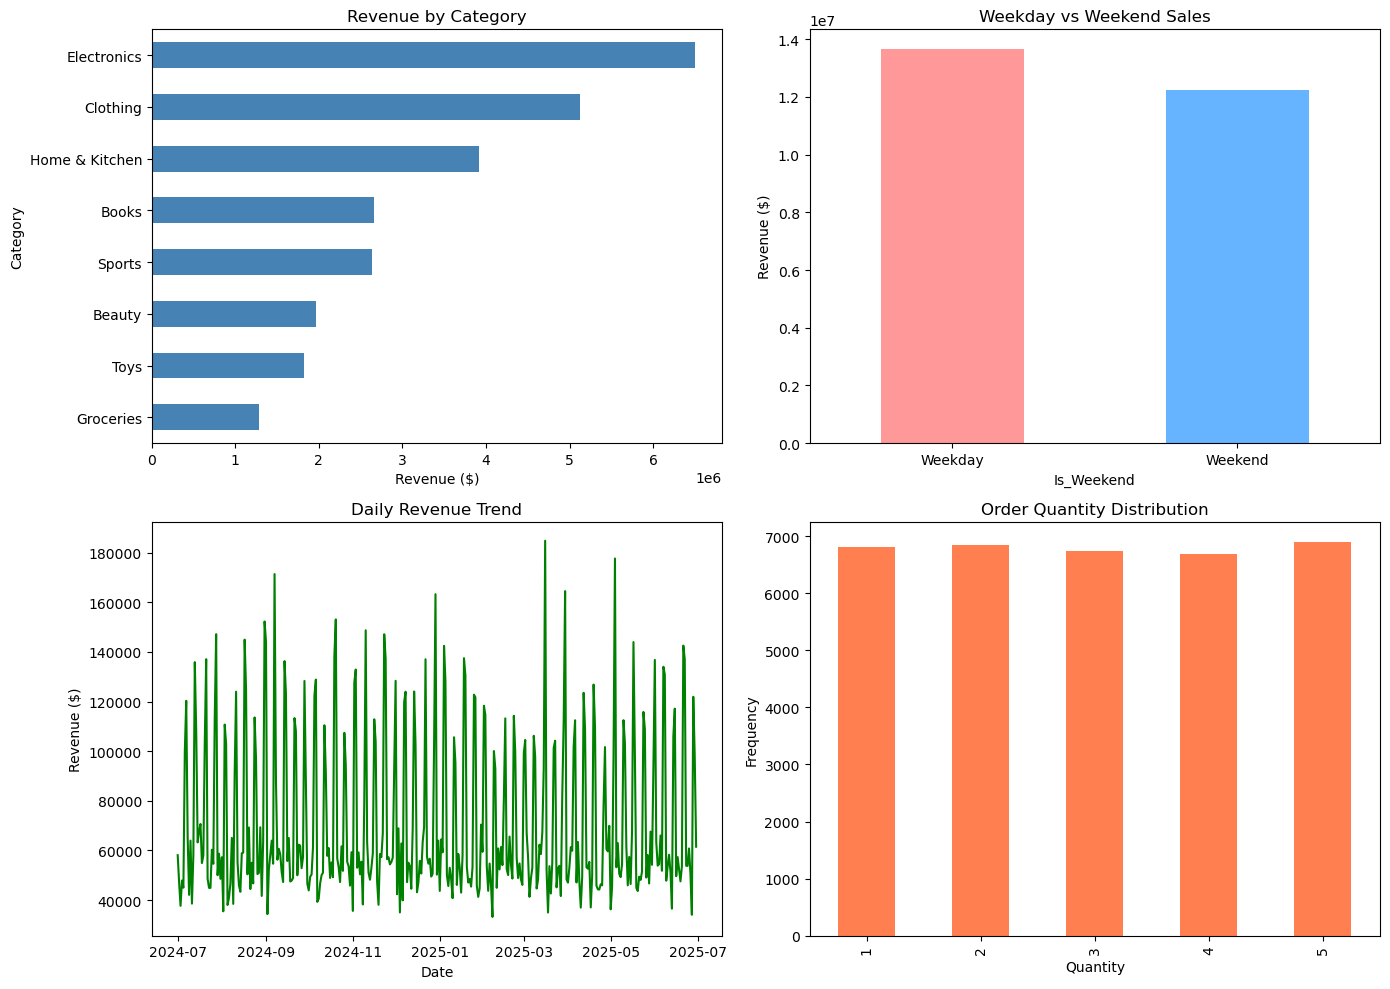

In [42]:
# Visualization 1: Category-wise Revenue
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]
category_revenue['Total_Revenue'].sort_values(ascending=True).plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_title('Revenue by Category')
ax1.set_xlabel('Revenue ($)')

# Visualization 2: Weekday vs Weekend
ax2 = axes[0, 1]
weekend_data = df.groupby('Is_Weekend')['Revenue'].sum()
weekend_data.plot(kind='bar', ax=ax2, color=['#ff9999', '#66b3ff'])
ax2.set_title('Weekday vs Weekend Sales')
ax2.set_ylabel('Revenue ($)')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

# Visualization 3: Daily Revenue Trend
ax3 = axes[1, 0]
daily_revenue = df.groupby(df['Date'].dt.date)['Revenue'].sum()
daily_revenue.plot(ax=ax3, color='green', linewidth=1.5)
ax3.set_title('Daily Revenue Trend')
ax3.set_ylabel('Revenue ($)')
ax3.set_xlabel('Date')

# Visualization 4: Order Frequency Distribution
ax4 = axes[1, 1]
df['Quantity'].value_counts().sort_index().plot(kind='bar', ax=ax4, color='coral')
ax4.set_title('Order Quantity Distribution')
ax4.set_ylabel('Frequency')
ax4.set_xlabel('Quantity')

plt.tight_layout()
plt.savefig('ecommerce_eda.png', dpi=300, bbox_inches='tight')
print("\n✅ Visualization saved as 'ecommerce_eda.png'")


In [28]:
# Statistical Summary
print("\n=== STATISTICAL SUMMARY ===")
print(df[['Quantity', 'Unit_Price', 'Revenue']].describe())


=== STATISTICAL SUMMARY ===
           Quantity    Unit_Price       Revenue
count  34007.000000  34007.000000  34007.000000
mean       3.000353    253.759309    761.943605
std        1.418491    141.527180    594.366108
min        1.000000     10.010000     10.170000
25%        2.000000    130.135000    284.270000
50%        3.000000    254.070000    597.420000
75%        4.000000    375.500000   1125.725000
max        5.000000    499.990000   2499.650000
